In [1]:
!pip install evaluate
!pip install torchinfo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support, classification_report
from typing import Dict, Any
from transformers import AutoModel, AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding, EarlyStoppingCallback
import evaluate
import torch
from torchinfo import summary
import warnings
warnings.filterwarnings('ignore')
import torch.nn as nn
from datasets import Dataset, DatasetDict

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
df_resenas_completo = pd.read_csv('/content/df_reviews_unificado_final.csv', engine='python', on_bad_lines='skip')
#df_resenas_completo = pd.read_csv('/content/df_limpio.csv', engine='python', on_bad_lines='skip')
#df_resenas_completo = pd.read_csv('/content/reviews_clean.csv', engine='python', on_bad_lines='skip')
df_resenas_completo.head()

,review,sentimiento,idioma
0,El fin de semana mi pareja y yo hicimos una re...,negativo,es
1,"El hotel en general está bien, las habtiacione...",neutro,es
2,"El hotel es moderno, amplio y limpio, pero no ...",neutro,es
3,Calefacción averiada o no operativa. Se coment...,negativo,es
4,Este hotel ha bajado notoriamente su categoria...,negativo,es


In [5]:
#df_resenas = df_resenas_completo[['review_norm', 'sentimiento']]
df_resenas = df_resenas_completo[['review', 'sentimiento']]
df_resenas.head()

,review,sentimiento
0,El fin de semana mi pareja y yo hicimos una re...,negativo
1,"El hotel en general está bien, las habtiacione...",neutro
2,"El hotel es moderno, amplio y limpio, pero no ...",neutro
3,Calefacción averiada o no operativa. Se coment...,negativo
4,Este hotel ha bajado notoriamente su categoria...,negativo


In [6]:
'''
df_resenas = df_resenas.rename(columns={'review_norm': 'review'})
df_resenas.head()
'''

"\ndf_resenas = df_resenas.rename(columns={'review_norm': 'review'})\ndf_resenas.head()\n"

In [7]:
df_resenas['sentimiento'].value_counts()

,count
sentimiento,
neutro,4492
positivo,2668
negativo,2585


In [8]:
#df_resenas_completo['idioma'].value_counts()

In [9]:
X = df_resenas.drop('sentimiento', axis=1)
y = df_resenas['sentimiento']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

df_train = pd.concat([X_train, y_train], axis=1)
df_val = pd.concat([X_val, y_val], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

print(f"Shape of training set: {df_train.shape}")
print(f"Shape of validation set: {df_val.shape}")
print(f"Shape of test set: {df_test.shape}")

print("\nDistribution of 'sentimiento' in training set:")
print(df_train['sentimiento'].value_counts(normalize=True))
print("\nDistribution of 'sentimiento' in validation set:")
print(df_val['sentimiento'].value_counts(normalize=True))
print("\nDistribution of 'sentimiento' in test set:")
print(df_test['sentimiento'].value_counts(normalize=True))

Shape of training set: (6821, 2)
Shape of validation set: (1462, 2)
Shape of test set: (1462, 2)

Distribution of 'sentimiento' in training set:
sentimiento
neutro      0.460929
positivo    0.273860
negativo    0.265210
Name: proportion, dtype: float64

Distribution of 'sentimiento' in validation set:
sentimiento
neutro      0.461012
positivo    0.273598
negativo    0.265390
Name: proportion, dtype: float64

Distribution of 'sentimiento' in test set:
sentimiento
neutro      0.461012
positivo    0.273598
negativo    0.265390
Name: proportion, dtype: float64


In [10]:
model_name = 'pysentimiento/robertuito-sentiment-analysis'
#model_name = 'nlptown/bert-base-multilingual-uncased-sentiment'

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer

config.json:   0%|          | 0.00/925 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

TokenizersBackend(name_or_path='pysentimiento/robertuito-sentiment-analysis', vocab_size=30000, model_max_length=128, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("<mask>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	430: AddedToken("@usuario", rstrip=False, lstrip=False, single_word=False, normalized=True, special=False),
	27394: AddedToken

In [11]:
id2label = {
    0: 'negativo',
    1: 'neutro',
    2: 'positivo'
}

label2id = {
    'negativo': 0,
    'neutro': 1,
    'positivo': 2
}

hf_train_dataset = Dataset.from_pandas(df_train)
hf_val_dataset = Dataset.from_pandas(df_val)
hf_test_dataset = Dataset.from_pandas(df_test)

dataset = DatasetDict({
    'train': hf_train_dataset,
    'validation': hf_val_dataset,
    'test': hf_test_dataset
})

max_length=128
def tokenize_function(examples):
    texts = [str(x).strip() for x in examples["review"]]

    tokenized = tokenizer(
        texts,
        truncation=True,
        max_length=max_length
    )

    tokenized["labels"] = [
        label2id[str(s).strip().lower()]
        for s in examples["sentimiento"]
    ]

    return tokenized


tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True
)


tokenized_dataset = tokenized_dataset.remove_columns(
    ['review', 'sentimiento']
)

if '__index_level_0__' in tokenized_dataset['train'].column_names:
    tokenized_dataset = tokenized_dataset.remove_columns(['__index_level_0__'])

Map:   0%|          | 0/6821 [00:00<?, ? examples/s]

Map:   0%|          | 0/1462 [00:00<?, ? examples/s]

Map:   0%|          | 0/1462 [00:00<?, ? examples/s]

In [12]:
output_directory = './csv_datasets'
import os
os.makedirs(output_directory, exist_ok=True)

# Save the training dataset
df_train_csv = dataset['train'].to_pandas()
df_train_csv.to_csv(f'{output_directory}/train_dataset.csv', index=False)
print(f"Training dataset saved to {output_directory}/tokenized_train_dataset.csv")

# Save the validation dataset
df_val_csv = dataset['validation'].to_pandas()
df_val_csv.to_csv(f'{output_directory}/validation_dataset.csv', index=False)
print(f"Validation dataset saved to {output_directory}/tokenized_validation_dataset.csv")

# Save the test dataset
df_test_csv = dataset['test'].to_pandas()
df_test_csv.to_csv(f'{output_directory}/test_dataset.csv', index=False)
print(f"Test dataset saved to {output_directory}/tokenized_test_dataset.csv")

Training dataset saved to ./csv_datasets/tokenized_train_dataset.csv
Validation dataset saved to ./csv_datasets/tokenized_validation_dataset.csv
Test dataset saved to ./csv_datasets/tokenized_test_dataset.csv


In [13]:
tokenized_dataset['train'].features

{'input_ids': List(Value('int32')),
 'attention_mask': List(Value('int8')),
 'labels': Value('int64')}

In [14]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0,1,2]),
    y=df_train['sentimiento'].map(label2id)
)

class_weights = torch.tensor(class_weights, dtype=torch.float)
#class_weights = torch.tensor([1,1,1], dtype=torch.float)
class_weights

tensor([1.2569, 0.7232, 1.2172])

In [15]:
from transformers.modeling_outputs import SequenceClassifierOutput

class CustomModel(nn.Module):
    def __init__(self, model_name, num_labels, class_weights=None):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        if class_weights is not None:
            self.register_buffer("class_weights", class_weights)
        else:
            self.class_weights = None

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_labels)
        )

    def mean_pooling(self, last_hidden_state, attention_mask):
        # Expand mask
        mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()

        # Sum embeddings considerando padding
        sum_embeddings = torch.sum(last_hidden_state * mask, dim=1)

        # Contar tokens válidos
        sum_mask = torch.clamp(mask.sum(dim=1), min=1e-9)

        # Promedio
        mean_embeddings = sum_embeddings / sum_mask

        return mean_embeddings

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # 🔥 Mean pooling (clave)
        pooled_output = self.mean_pooling(
            outputs.last_hidden_state,
            attention_mask
        )

        logits = self.classifier(pooled_output)

        loss = None
        if labels is not None:
            labels = labels.long()

            if self.class_weights is not None:
                loss_fn = nn.CrossEntropyLoss(
                    weight=self.class_weights.to(logits.device)
                )
            else:
                loss_fn = nn.CrossEntropyLoss()

            loss = loss_fn(logits, labels)

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits
        )

In [16]:
model = CustomModel(
    model_name=model_name,
    num_labels=len(id2label),
    class_weights=class_weights
)

model.safetensors:   0%|          | 0.00/435M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: pysentimiento/robertuito-sentiment-analysis
Key                             | Status     | 
--------------------------------+------------+-
classifier.dense.bias           | UNEXPECTED | 
classifier.dense.weight         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | UNEXPECTED | 
classifier.out_proj.weight      | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [17]:
for param in model.encoder.parameters():
    param.requires_grad = False

In [18]:
# Create dummy input data with the correct data type
dummy_input_ids = torch.randint(
    0, model.encoder.config.vocab_size,
    (1, max_length),
    dtype=torch.long
)


dummy_attention_mask = torch.ones(
    (1, max_length),
    dtype=torch.long
)

# Pass input_data as a dictionary to summary
summary(
    model,
    input_data={
        'input_ids': dummy_input_ids,
        'attention_mask': dummy_attention_mask
    }
)


Layer (type:depth-idx)                                       Output Shape              Param #
CustomModel                                                  [1, 3]                    --
├─RobertaModel: 1-1                                          [1, 768]                  --
│    └─RobertaEmbeddings: 2-1                                [1, 128, 768]             --
│    │    └─Embedding: 3-1                                   [1, 128, 768]             (23,041,536)
│    │    └─Embedding: 3-2                                   [1, 128, 768]             (768)
│    │    └─Embedding: 3-3                                   [1, 128, 768]             (99,840)
│    │    └─LayerNorm: 3-4                                   [1, 128, 768]             (1,536)
│    │    └─Dropout: 3-5                                     [1, 128, 768]             --
│    └─RobertaEncoder: 2-2                                   [1, 128, 768]             --
│    │    └─ModuleList: 3-6                                  --        

In [19]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='weighted'
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [20]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

batch_size = 8
logging_steps = len(tokenized_dataset['train']) // batch_size

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Definimos los parámetros globales de entrenamiento
training_args = TrainingArguments(
    output_dir='./hf',
    num_train_epochs=10,
    learning_rate=5e-5,
    lr_scheduler_type="linear",
    #warmup_steps=10,
    per_device_eval_batch_size=batch_size,
    per_device_train_batch_size=batch_size,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    disable_tqdm=False,
    logging_steps=logging_steps,
    metric_for_best_model="f1"
)

# Y definimos el entrenador, especificando el modelo, datasets y el tokenizador
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['validation'],
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [21]:
print(f"Tokenizer vocab size: {tokenizer.vocab_size}")
print(f"Model encoder vocab size: {model.encoder.config.vocab_size}")

Tokenizer vocab size: 30000
Model encoder vocab size: 30002


In [37]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.338572,0.321621,0.873461,0.873595,0.874631,0.873461
2,0.326240,0.312969,0.865253,0.865364,0.870281,0.865253
3,0.317414,0.320665,0.875513,0.875513,0.875513,0.875513
4,0.309051,0.307620,0.872777,0.872643,0.872576,0.872777
5,0.299747,0.306984,0.875513,0.875838,0.877682,0.875513
6,0.297123,0.300513,0.876197,0.876210,0.877093,0.876197
7,0.286414,0.303465,0.871409,0.871665,0.876524,0.871409
8,0.283661,0.307204,0.878933,0.879097,0.879396,0.878933
9,0.280566,0.303267,0.880301,0.880365,0.880829,0.880301
10,0.282982,0.302634,0.880301,0.880365,0.880829,0.880301


TrainOutput(global_step=8530, training_loss=0.30204845743749514, metrics={'train_runtime': 929.5197, 'train_samples_per_second': 73.382, 'train_steps_per_second': 9.177, 'total_flos': 0.0, 'train_loss': 0.30204845743749514, 'epoch': 10.0})

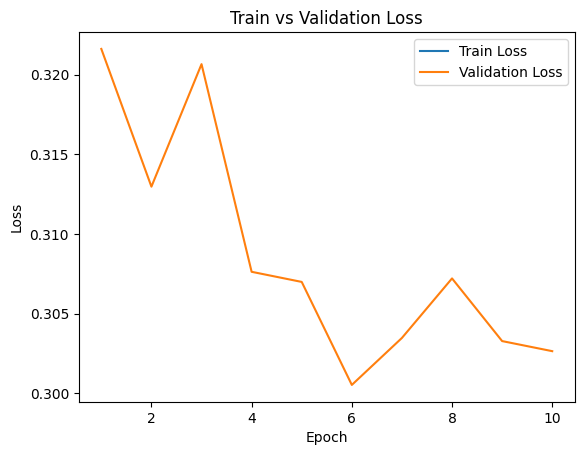

In [38]:
logs = trainer.state.log_history
df_logs = pd.DataFrame(logs)

train_logs = df_logs[df_logs['train_loss'].notna()]
# métricas de validación
eval_logs = df_logs[df_logs['eval_loss'].notna()]

plt.plot(train_logs['epoch'], train_logs['loss'], label='Train Loss')
plt.plot(eval_logs['epoch'], eval_logs['eval_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.show()

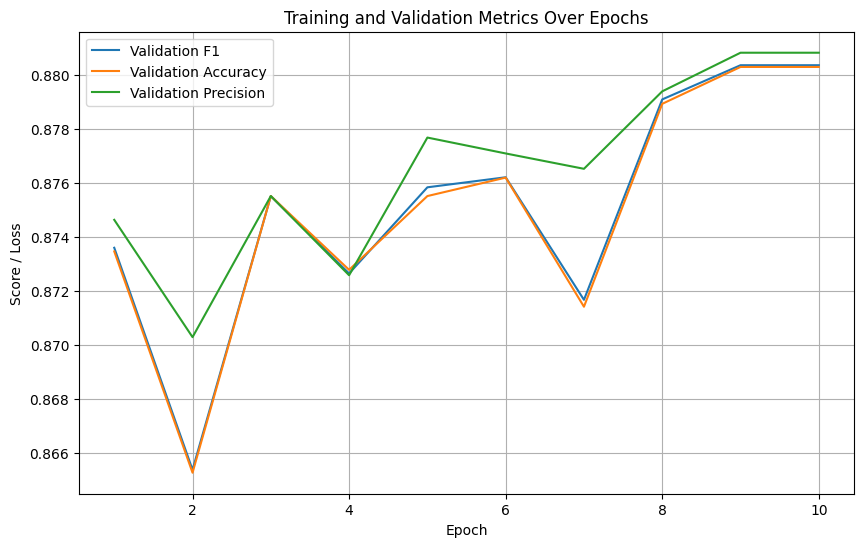

In [39]:
plt.figure(figsize=(10, 6))
plt.plot(eval_logs['epoch'], eval_logs['eval_f1'], label='Validation F1')
plt.plot(eval_logs['epoch'], eval_logs['eval_accuracy'], label='Validation Accuracy')
plt.plot(eval_logs['epoch'], eval_logs['eval_precision'], label='Validation Precision')

plt.xlabel('Epoch')
plt.ylabel('Score / Loss')
plt.title('Training and Validation Metrics Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [40]:
model.eval()
trainer.evaluate(tokenized_dataset['test'])

{'eval_loss': 0.26867443323135376,
 'eval_accuracy': 0.8967168262653898,
 'eval_f1': 0.8966449873692328,
 'eval_precision': 0.8973396744896639,
 'eval_recall': 0.8967168262653898,
 'eval_runtime': 11.1901,
 'eval_samples_per_second': 130.651,
 'eval_steps_per_second': 16.354,
 'epoch': 10.0}

In [41]:
predictions = trainer.predict(tokenized_dataset['test'])
predictions

PredictionOutput(predictions=array([[ 1.7169887,  0.5787496, -3.3376143],
       [-3.9660633,  4.5916   , -4.0143633],
       [ 4.0519085, -1.2362182, -3.5030808],
       ...,
       [-3.249084 ,  4.05089  , -3.8696198],
       [-2.7488196,  3.9885952, -4.001277 ],
       [-2.9738193, -0.6453531,  1.9362769]], dtype=float32), label_ids=array([1, 1, 0, ..., 1, 1, 1]), metrics={'test_loss': 0.26867443323135376, 'test_accuracy': 0.8967168262653898, 'test_f1': 0.8966449873692328, 'test_precision': 0.8973396744896639, 'test_recall': 0.8967168262653898, 'test_runtime': 11.47, 'test_samples_per_second': 127.463, 'test_steps_per_second': 15.955})

In [42]:
predicted_labels = np.argmax(predictions.predictions, axis=-1)
test_set = tokenized_dataset['test']
# 'category' ya viene en el split de test; no duplicar columna
if 'category' not in test_set.column_names:
    test_set = test_set.add_column(
        'category', [id2label[int(i)] for i in test_set['labels']]
    )
test_set = test_set.add_column('prediction_label', predicted_labels)
test_set = test_set.add_column('prediction', list(map(lambda label: id2label[label], predicted_labels)))
test_set

Dataset({
    features: ['input_ids', 'attention_mask', 'labels', 'category', 'prediction_label', 'prediction'],
    num_rows: 1462
})

In [43]:
from sklearn.metrics import classification_report
print(classification_report(
    predictions.label_ids,
    predicted_labels,
    target_names=['negativo', 'neutro', 'positivo']
))

              precision    recall  f1-score   support

    negativo       0.87      0.90      0.89       388
      neutro       0.91      0.87      0.89       674
    positivo       0.90      0.93      0.91       400

    accuracy                           0.90      1462
   macro avg       0.89      0.90      0.90      1462
weighted avg       0.90      0.90      0.90      1462



In [44]:
df_test_predictions = test_set.to_pandas()
df_display = df_test.reset_index(drop=True).merge(df_test_predictions[['prediction', 'category']], left_index=True, right_index=True)
df_display = df_display[['review', 'sentimiento', 'prediction']].rename(columns={'sentimiento': 'true_sentiment'})
df_display.head(10)

,review,true_sentiment,prediction
0,Tuvimos la 'suerte' de que nos dieron una habi...,neutro,negativo
1,La atencion fue excelente. igual el servicio f...,neutro,neutro
2,nunca volveré y tampoco lo recomendaré . Es u...,negativo,negativo
3,El desayuno estuvo muy rico. eso si se escucha...,neutro,neutro
4,La ubicación es muy buena. aunque falta manten...,neutro,neutro
5,"El hotel esta bastante bien, el desayuno es co...",neutro,negativo
6,"Habitacion espaciosa y limpia, eso si el preci...",neutro,neutro
7,"La habitación doble era una cama de 1,35 en un...",negativo,negativo
8,Muy bien ubicado. Está muy bien conservado. La...,positivo,neutro
9,"DOS EDIFICIOS, entras y hay habitaciones y lue...",negativo,negativo


In [45]:
df_misclassified = df_display[df_display['true_sentiment'] != df_display['prediction']]

print("Misclassified instances: ", len(df_misclassified))
df_misclassified.head(10)

Misclassified instances:  151


,review,true_sentiment,prediction
0,Tuvimos la 'suerte' de que nos dieron una habi...,neutro,negativo
5,"El hotel esta bastante bien, el desayuno es co...",neutro,negativo
8,Muy bien ubicado. Está muy bien conservado. La...,positivo,neutro
45,Os voy a contar mi experiencia. Somos una pare...,neutro,negativo
51,Reservamos una habitación con una cama de matr...,neutro,negativo
57,"Hola, buenas tardes. Les escribo para notific...",neutro,negativo
62,"Estuve una única noche, la recepción y el hote...",neutro,negativo
64,"El hotel es bonito, muy bien decorado, pero cl...",neutro,negativo
67,Me he hospedado un par de veces en este hotel ...,neutro,positivo
73,El hostal está estupendo. Pagamos 35€ la noche...,positivo,neutro


In [46]:
misclassification_summary = df_misclassified.groupby(['true_sentiment', 'prediction']).size().reset_index(name='count')
print("Misclassification Summary: ", len(df_misclassified))
misclassification_summary

Misclassification Summary:  151


,true_sentiment,prediction,count
0,negativo,neutro,30
1,negativo,positivo,7
2,neutro,negativo,51
3,neutro,positivo,35
4,positivo,negativo,2
5,positivo,neutro,26


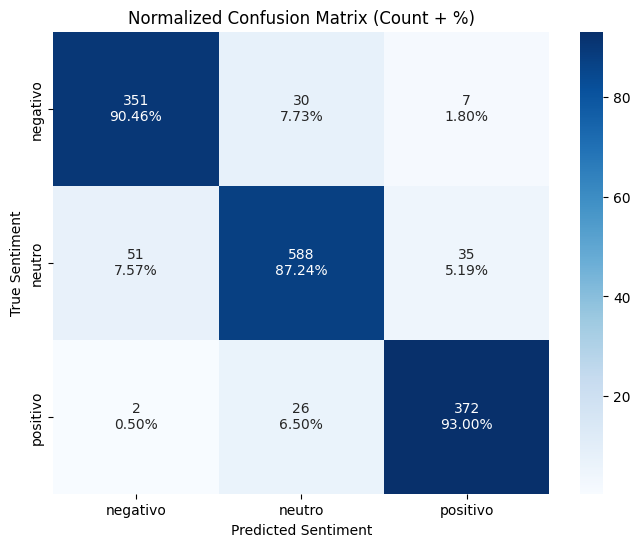

In [47]:
cm = confusion_matrix(
    df_display['true_sentiment'],
    df_display['prediction'],
    labels=['negativo', 'neutro', 'positivo']
)

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Crear etiquetas combinadas: conteo + porcentaje
labels = np.empty_like(cm).astype(str)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        percent = cm_normalized[i, j] * 100
        labels[i, j] = f"{count}\n{percent:.2f}%"

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized * 100,
    annot=labels,   # 👈 usamos nuestras etiquetas
    fmt="",
    cmap='Blues',
    xticklabels=['negativo', 'neutro', 'positivo'],
    yticklabels=['negativo', 'neutro', 'positivo']
)

plt.xlabel('Predicted Sentiment')
plt.ylabel('True Sentiment')
plt.title('Normalized Confusion Matrix (Count + %)')
plt.show()

In [48]:
import json
output_dir = "./modelo_final"

trainer.save_model(output_dir)       # guarda modelo + config
tokenizer.save_pretrained(output_dir)
# trainer.args.save(output_dir) # This line caused an AttributeError

metrics = trainer.evaluate()

with open(f"{output_dir}/metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

with open(f"{output_dir}/label_mapping.json", "w") as f:
    json.dump({"id2label": id2label, "label2id": label2id}, f)


In [49]:
import os

output_dir = "./modelo_final"

# List the contents of the output directory
print(f"Contents of '{output_dir}':\n{os.listdir(output_dir)}")

# You should see 'vocab.json' and 'merges.txt' which are the equivalent for this tokenizer.
if 'vocab.json' in os.listdir(output_dir) and 'merges.txt' in os.listdir(output_dir):
    print("\nConfirmation: vocab.json and merges.txt (the equivalent vocabulary files for RobertaTokenizer) are present in the modelo_final directory.")
else:
    print("\nWarning: vocab.json or merges.txt were not found in the modelo_final directory. Please ensure the tokenizer was saved correctly.")

Contents of './modelo_final':
['model.safetensors', 'tokenizer.json', 'metrics.json', 'training_args.bin', 'label_mapping.json', 'tokenizer_config.json']

